# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**
1. Jacobo Diaz Alvarado

2. Diego Andrés Ortiz Sanabria

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**
$$ \frac{e^{-z}}{(1+e^{-z})^2} = Φ (1 - Φ) $$

---
**Derivada función ReLU**
$$
f'(x) =
\begin{cases}
0 & \text{si } x < 0 \\
1 & \text{si } x > 0
\end{cases}
$$

---
**Derivada función de costo: Entropia Cruzada**

$$ \frac{\partial E}{\partial {Φ}} = - \left( \frac{Y}{{Φ}} - \frac{1 - Y}{1 - {Φ}} \right) $$


## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [2]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

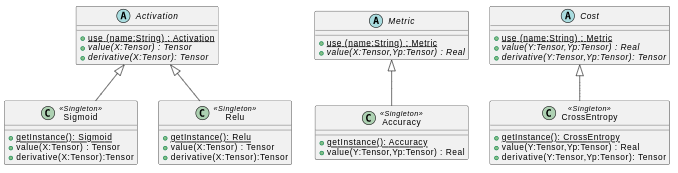

### MÉTRICA

In [6]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa la metrica de una red neuronal
  """
  @abstractmethod
  def use(self, name: str):
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la metrica
    Returns:
      self (Metric): objeto metrica
    """
    pass
  
  @abstractmethod
  def value(self, Y: np.ndarray, Yp:np.ndarray):
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    pass
  


In [7]:
####### Clase Accuracy #######
class Accuracy(Metric):
  _instance = None 
  
  def __new__(cls):
    """Controla la creación de la instancia para garantizar el patrón Singleton."""
    if cls._instance is None:
      cls._instance = super().__new__(cls)
    return cls._instance
  
  @staticmethod
  def getInstance():
    """Retorna la única instancia de Accuracy (patrón Singleton)."""
    return Accuracy()
  
  def use(self, name: str):
  ###Obtiene la métrica correspondiente al nombre dado.
    if name == "accuracy":
      return Accuracy.getInstance()
    raise ValueError(f"Métrica no encontrada: {name}")
  
  def value(self, Y, Yp):
  ###Computa el accuracy comparando salidas esperadas contra las obtenidas
    return np.mean(Y == Yp)

In [8]:
# Adicione los casos de prueba de los métodos implementados

# 1. Singleton: ambas variables deben ser el mismo objeto
a1 = Accuracy.getInstance()
a2 = Accuracy.getInstance()
assert a1 is a2, "Singleton falló: son instancias distintas"
print("Singleton OK")

# 2. use() con nombre válido: debe retornar instancia de Accuracy
metrica = a1.use("accuracy")
assert isinstance(metrica, Accuracy), "use() no retornó una instancia de Accuracy"
print("use('accuracy') OK")

# 3. value() todo correcto: accuracy debe ser 1.0
Y  = np.array([1, 0, 1, 1])
Yp = np.array([1, 0, 1, 1])
resultado = a1.value(Y, Yp)
assert resultado == 1.0, f"Esperado 1.0, obtenido {resultado}"
print(f" value() perfecto OK — {resultado}")

# 4. value() parcialmente correcto: 3 de 4 = 0.75
Y  = np.array([1, 0, 1, 1])
Yp = np.array([1, 0, 0, 1])
resultado = a1.value(Y, Yp)
assert resultado == 0.75, f"Esperado 0.75, obtenido {resultado}"
print(f"value() parcial OK — {resultado}")

Singleton OK
use('accuracy') OK
 value() perfecto OK — 1.0
value() parcial OK — 0.75


### COSTO

In [9]:
class Cost(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
  Representa la función de costo o error de una red neuronal
  """
  @abstractmethod
  def use(self, name: str):
    """ obtiene función de costo (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Cost): objeto función de costo
    """
    pass
  @abstractmethod
  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      S (float): valor de computo de la función de costo
    """
    pass
  @abstractmethod
  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de costo
    """
    pass

NameError: name 'self' is not defined

In [10]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
  """ Función de costo Entropia Cruzada. Implementa Cost
  """
  _instance = None
  
  def __new__(cls):
    if cls._instance is None:
      cls._instance = super().__new__(cls)
    return cls._instance
  
  @staticmethod
  def getInstance():
    return CrossEntropy()
  
  def use(self, name: str):
    if name == "crossentropy":
      return CrossEntropy.getInstance()
    raise ValueError (f"Función de costo no encontrada: {name}")
  

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    return -np.mean(Y * np.log(Yp) + (1 - Y) * np.log(1-Yp))

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    return -(Y / Yp) + (1 - Y)/(1 - Yp)

In [11]:
# Adicione los casos de prueba de los métodos implementados
#1. Singleton: ambas variables deben ser el mismo objeto
c1 = CrossEntropy.getInstance()
c2 = CrossEntropy.getInstance()
assert c1 is c2, "Singleton falló: son instancias distintas"
print("Singleton OK")

# 2. use() con nombre válido
costo = c1.use("crossentropy")
assert isinstance(costo, CrossEntropy), "use() no retornó una instancia de CrossEntropy"
print("use('crosentropy') OK")

# 3. value() - resultado debe ser un float positivo
Y = np.array([1,0,1,0])
Yp = np.array([0.9, 0.1, 0.8, 0.2])
resultado = c1.value(Y, Yp)
assert isinstance(resultado, float), "value() no retornó un float"
assert resultado > 0, "value() debe ser positivo"
print(f"value() OK - {resultado:.4f}")


# 4. derivative() — debe retornar ndarray del mismo tamaño que Y
Y  = np.array([1, 0, 1, 0])
Yp = np.array([0.9, 0.1, 0.8, 0.2])
grad = c1.derivative(Y, Yp)
assert isinstance(grad, np.ndarray), "derivative() no retornó un ndarray"
assert grad.shape == Y.shape, "derivative() debe tener el mismo tamaño que Y"
print(f"derivative() OK — {grad}")

Singleton OK
use('crosentropy') OK
value() OK - 0.1643
derivative() OK — [-1.11111111  1.11111111 -1.25        1.25      ]


### ACTIVACION

In [12]:
class Activation(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave de cualquier función de activación
  Representa la función de activación de cualquier neurona en la red neuronal
  """
  @abstractmethod
  def use(self, name: str):
    """ obtiene función de activación (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Activation): objeto función de activación
    """
    pass
  @abstractmethod
  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    pass
  @abstractmethod
  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    pass

In [13]:
# Documentar los métodos implementados
class Sigmoid(Activation):
  """ Función de activación sigmoide. Implementa Activación
  """
  _instance = None
  
  def __new__(cls):
    if cls._instance is None:
      cls._instance = super().__new__(cls)
    return cls._instance
  
  @staticmethod
  def getInstance():
    return Sigmoid()
  
  def use(self, name: str):
    if(name == "sigmoid"):
      return Sigmoid.getInstance()
    elif (name == "relu"):
      return Relu.getInstance()
    raise ValueError (f"Activación no encontrada: {name}" )

  def value(self, X: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-X))

  def derivative(self, X: np.ndarray) -> np.ndarray:
    s = self.value(X)
    return s * (1 - s)

In [14]:
# Documentar los métodos implementados
class Relu(Activation):
  """ Función de activación RELU. Implementa Activación
  """
  _instance = None
  
  def __new__(cls):
    if cls._instance is None:
      cls._instance = super().__new__(cls)
    return cls._instance
  
  @staticmethod
  def getInstance():
    return Relu()
  
  def use(self, name: str):
    if(name == "sigmoid"):
      return Sigmoid.getInstance()
    elif (name == "relu"):
      return Relu.getInstance()
    raise ValueError (f"Activación no encontrada: {name}" )

  def value(self, X: np.ndarray) -> np.ndarray:
    return np.maximum(0, X)

  def derivative(self, X: np.ndarray) -> np.ndarray:
    return (X > 0).astype(float)

In [15]:
# Adicione los casos de prueba de los métodos implementados

# 1. Singleton
s1 = Sigmoid.getInstance()
s2 = Sigmoid.getInstance()
assert s1 is s2, "Singleton falló: son instancias distintas"
print("Sigmoid Singleton OK")

# 2. use() con nombre válido "sigmoid"
act = s1.use("sigmoid")
assert isinstance(act, Sigmoid), "use() no retornó una instancia de Sigmoid"
print("Sigmoid use('sigmoid') OK")

# 3. use() con nombre válido "relu"
act = s1.use("relu")
assert isinstance(act, Relu), "use() no retornó una instancia de Relu"
print("Sigmoid use('relu') OK")

# 4. value() — salida debe estar entre 0 y 1
X = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
result = s1.value(X)
assert np.all(result > 0) and np.all(result < 1), "value() debe estar entre 0 y 1"
print(f"Sigmoid value() OK — {result}")

# 5. value() — en 0 debe dar exactamente 0.5
assert np.isclose(s1.value(np.array([0.0]))[0], 0.5), "value(0) debe ser 0.5"
print("Sigmoid value(0) = 0.5 OK")

# 6. derivative() — debe retornar ndarray del mismo tamaño
X = np.array([-1.0, 0.0, 1.0])
grad = s1.derivative(X)
assert grad.shape == X.shape, "derivative() debe tener el mismo tamaño que X"
assert np.all(grad > 0), "derivative() de sigmoid siempre es positiva"
print(f"Sigmoid derivative() OK — {grad}")

# 7. Singleton
r1 = Relu.getInstance()
r2 = Relu.getInstance()
assert r1 is r2, "Singleton falló: son instancias distintas"
print("Relu Singleton OK")

# 6. use() con nombre válido "relu"
act = r1.use("relu")
assert isinstance(act, Relu), "use() no retornó una instancia de Relu"
print("Relu use('relu') OK")

# 7. use() con nombre válido "sigmoid"
act = r1.use("sigmoid")
assert isinstance(act, Sigmoid), "use() no retornó una instancia de Sigmoid"
print("Relu use('sigmoid') OK")

# 8. value() — negativos deben ser 0, positivos se mantienen
X = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
result = r1.value(X)
expected = np.array([0.0, 0.0, 0.0, 1.0, 2.0])
assert np.allclose(result, expected), f"value() incorrecto: {result}"
print(f" Relu value() OK — {result}")

# 9. derivative() — 1 donde X > 0, 0 donde X <= 0
X = np.array([-1.0, 0.0, 1.0, 2.0])
grad = r1.derivative(X)
expected = np.array([0.0, 0.0, 1.0, 1.0])
assert np.allclose(grad, expected), f"derivative() incorrecto: {grad}"
print(f" Relu derivative() OK — {grad}")


Sigmoid Singleton OK
Sigmoid use('sigmoid') OK
Sigmoid use('relu') OK
Sigmoid value() OK — [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Sigmoid value(0) = 0.5 OK
Sigmoid derivative() OK — [0.19661193 0.25       0.19661193]
Relu Singleton OK
Relu use('relu') OK
Relu use('sigmoid') OK
 Relu value() OK — [0. 0. 0. 1. 2.]
 Relu derivative() OK — [0. 0. 1. 1.]


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

#### Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**

$$ \frac{\partial E}{\partial Z} = \frac{\partial E}{\partial \Phi} \cdot \frac{\partial \Phi}{\partial Z} $$

$$ = -\left( \frac{Y}{\Phi} - \frac{1-Y}{1-\Phi} \right) \cdot \Phi(1-\Phi) $$

$$ = -\left( Y(1-\Phi) - (1-Y) \cdot \Phi \right) $$

$$ = -Y + Y\Phi + \Phi - Y\Phi $$

$$ = \Phi - Y $$

$$ dW = \frac{1}{m} \cdot dZ \cdot X^T $$

---
**Gradiente db**

$$ \frac{\partial Z}{\partial b} = 1 $$

$$ \frac{\partial E}{\partial b} = \frac{\partial E}{\partial Z} \cdot \frac{\partial Z}{\partial b} = dZ \cdot 1 = dZ $$

$$ db = \frac{1}{m} \sum dZ $$

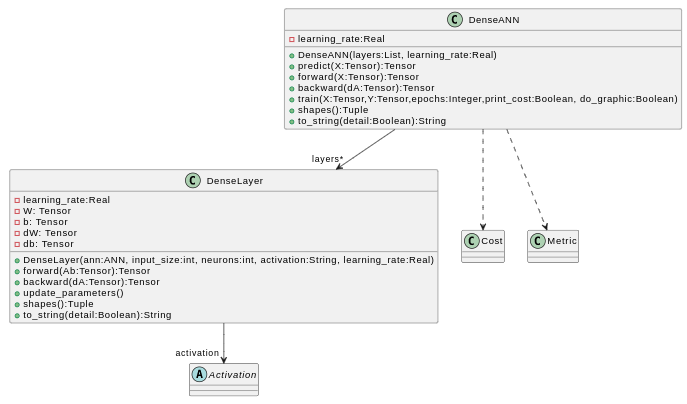

# Funciones Auxiliares

In [2]:
import numpy as np

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def d_sigmoid(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def d_relu(Z):
    return (Z > 0).astype(float)

In [3]:
class DenseANN:
    def __init__(self, layers, learning_rate):
        self.learning_rate = learning_rate
        self.layers = []
        
        for i in range(1, len(layers)):
            act = "sigmoid" if i == len(layers)-1 else "relu"
            self.layers.append(
                DenseLayer(layers[i-1], layers[i], act, learning_rate)
            )

    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def predict(self, X):
        Yp = self.forward(X)
        return (Yp > 0.5).astype(int)

    def backward(self, Yp, Y):
        m = Y.shape[1]
        dA = -(Y/Yp - (1-Y)/(1-Yp))  # derivada BCE
        
        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    def train(self, X, Y, epochs=1000, print_cost=True):
        for i in range(epochs):
            Yp = self.forward(X)
            
            cost = -np.mean(Y*np.log(Yp+1e-8) + (1-Y)*np.log(1-Yp+1e-8))
            
            self.backward(Yp, Y)
            
            for layer in self.layers:
                layer.update_parameters()
            
            if print_cost and i % 100 == 0:
                print(f"Epoch {i}, Cost: {cost:.4f}")

    def shapes(self):
        return [layer.shapes() for layer in self.layers]

## CAPA CON PERCEPTRONES

In [4]:
class DenseLayer:
    def __init__(self, input_size, neurons, activation, learning_rate):
        self.learning_rate = learning_rate
        self.activation_name = activation
        
        self.W = np.random.randn(neurons, input_size) * 0.01
        self.b = np.zeros((neurons, 1))
        
        self.dW = None
        self.db = None
        
        self.Z = None
        self.A = None

    def activation(self, Z):
        if self.activation_name == "sigmoid":
            return sigmoid(Z)
        elif self.activation_name == "relu":
            return relu(Z)

    def activation_derivative(self, A):
        if self.activation_name == "sigmoid":
            return d_sigmoid(A)
        elif self.activation_name == "relu":
            return d_relu(A)

    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = np.dot(self.W, A_prev) + self.b
        self.A = self.activation(self.Z)
        return self.A

    def backward(self, dA):
        m = self.A_prev.shape[1]
        
        dZ = dA * self.activation_derivative(self.A)
        self.dW = (1/m) * np.dot(dZ, self.A_prev.T)
        self.db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        dA_prev = np.dot(self.W.T, dZ)
        return dA_prev

    def update_parameters(self):
        self.W -= self.learning_rate * self.dW
        self.b -= self.learning_rate * self.db

    def shapes(self):
        return self.W.shape

In [16]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.

# Datos AND
X = np.array([[0,0,1,1],
              [0,1,0,1]])  # (2,4)

Y = np.array([[0,0,0,1]])  # (1,4)

# Crear red (2 entradas -> 1 salida)
ann = DenseANN([2,1], learning_rate=0.1)

ann.train(X, Y, epochs=1000)

print("Predicciones:")
print(ann.predict(X))

Epoch 0, Cost: 0.6931
Epoch 100, Cost: 0.4624
Epoch 200, Cost: 0.3633
Epoch 300, Cost: 0.3019
Epoch 400, Cost: 0.2596
Epoch 500, Cost: 0.2283
Epoch 600, Cost: 0.2040
Epoch 700, Cost: 0.1845
Epoch 800, Cost: 0.1684
Epoch 900, Cost: 0.1549
Predicciones:
[[0 0 0 1]]


In [17]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.
X = np.array([[0,0,1,1],
              [0,1,0,1]])

Y = np.array([[0,1,1,1]])

ann = DenseANN([2,1], learning_rate=0.1)
ann.train(X, Y, epochs=1000)

print("Predicciones:")
print(ann.predict(X))

Epoch 0, Cost: 0.6905
Epoch 100, Cost: 0.3418
Epoch 200, Cost: 0.2666
Epoch 300, Cost: 0.2172
Epoch 400, Cost: 0.1824
Epoch 500, Cost: 0.1567
Epoch 600, Cost: 0.1370
Epoch 700, Cost: 0.1215
Epoch 800, Cost: 0.1089
Epoch 900, Cost: 0.0986
Predicciones:
[[0 1 1 1]]


In [18]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.
# Datos XOR
X = np.array([[0,0,1,1],
              [0,1,0,1]])

Y = np.array([[0,1,1,0]])

# Red más robusta
ann = DenseANN([2,4,1], learning_rate=0.5)

# Entrenamiento
ann.train(X, Y, epochs=10000)

print("Predicciones:")
print(ann.predict(X))

Epoch 0, Cost: 0.6931
Epoch 100, Cost: 0.6510
Epoch 200, Cost: 0.4275
Epoch 300, Cost: 0.0551
Epoch 400, Cost: 0.0164
Epoch 500, Cost: 0.0084
Epoch 600, Cost: 0.0053
Epoch 700, Cost: 0.0038
Epoch 800, Cost: 0.0029
Epoch 900, Cost: 0.0024
Epoch 1000, Cost: 0.0020
Epoch 1100, Cost: 0.0017
Epoch 1200, Cost: 0.0014
Epoch 1300, Cost: 0.0013
Epoch 1400, Cost: 0.0011
Epoch 1500, Cost: 0.0010
Epoch 1600, Cost: 0.0009
Epoch 1700, Cost: 0.0009
Epoch 1800, Cost: 0.0008
Epoch 1900, Cost: 0.0007
Epoch 2000, Cost: 0.0007
Epoch 2100, Cost: 0.0006
Epoch 2200, Cost: 0.0006
Epoch 2300, Cost: 0.0006
Epoch 2400, Cost: 0.0005
Epoch 2500, Cost: 0.0005
Epoch 2600, Cost: 0.0005
Epoch 2700, Cost: 0.0004
Epoch 2800, Cost: 0.0004
Epoch 2900, Cost: 0.0004
Epoch 3000, Cost: 0.0004
Epoch 3100, Cost: 0.0004
Epoch 3200, Cost: 0.0004
Epoch 3300, Cost: 0.0003
Epoch 3400, Cost: 0.0003
Epoch 3500, Cost: 0.0003
Epoch 3600, Cost: 0.0003
Epoch 3700, Cost: 0.0003
Epoch 3800, Cost: 0.0003
Epoch 3900, Cost: 0.0003
Epoch 4000, 

In [19]:
# Como cuarto caso de prueba entrene un perceptrón multicapa [2,2,1] para calcular el operador lógico xor. Explique los resultados
# Datos XOR
X = np.array([[0, 0], 
              [0, 1], 
              [1, 0], 
              [1, 1]]).T  

Y = np.array([[0], 
              [1], 
              [1], 
              [0]]).T      

# Red neuronal
np.random.seed(0)
ann = DenseANN([2,2,1], learning_rate=0.5)

# Entrenamiento
ann.train(X, Y, epochs=10000)

# Predicción
predictions = ann.predict(X)
print("Predicciones:")
print(predictions)

# Precisión
accuracy = Accuracy()
acc = accuracy.value(Y, predictions)
print(f"Precisión: {acc}")

Epoch 0, Cost: 0.6931
Epoch 100, Cost: 0.6862
Epoch 200, Cost: 0.5055
Epoch 300, Cost: 0.1140
Epoch 400, Cost: 0.0392
Epoch 500, Cost: 0.0218
Epoch 600, Cost: 0.0145
Epoch 700, Cost: 0.0108
Epoch 800, Cost: 0.0085
Epoch 900, Cost: 0.0070
Epoch 1000, Cost: 0.0060
Epoch 1100, Cost: 0.0051
Epoch 1200, Cost: 0.0045
Epoch 1300, Cost: 0.0040
Epoch 1400, Cost: 0.0036
Epoch 1500, Cost: 0.0033
Epoch 1600, Cost: 0.0030
Epoch 1700, Cost: 0.0028
Epoch 1800, Cost: 0.0026
Epoch 1900, Cost: 0.0024
Epoch 2000, Cost: 0.0023
Epoch 2100, Cost: 0.0021
Epoch 2200, Cost: 0.0020
Epoch 2300, Cost: 0.0019
Epoch 2400, Cost: 0.0018
Epoch 2500, Cost: 0.0017
Epoch 2600, Cost: 0.0016
Epoch 2700, Cost: 0.0016
Epoch 2800, Cost: 0.0015
Epoch 2900, Cost: 0.0014
Epoch 3000, Cost: 0.0014
Epoch 3100, Cost: 0.0013
Epoch 3200, Cost: 0.0013
Epoch 3300, Cost: 0.0012
Epoch 3400, Cost: 0.0012
Epoch 3500, Cost: 0.0011
Epoch 3600, Cost: 0.0011
Epoch 3700, Cost: 0.0011
Epoch 3800, Cost: 0.0010
Epoch 3900, Cost: 0.0010
Epoch 4000, 

In [ ]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Cargar datos ---
df = pd.read_csv("BEED_Data.csv")
X = df.drop(columns=["y"]).values  # (8000, 16)
y = df["y"].values                  # clases 0,1,2,3

# --- 2. Binarizar: seizure (1,2,3) vs sano (0) ---
# La red usa sigmoid → salida binaria
y_bin = (y > 0).astype(int)  # 0=sano, 1=cualquier tipo de seizure

# --- 3. Normalizar ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. Split 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_bin,
    test_size=0.20,
    random_state=42,
    stratify=y_bin
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

# Formato requerido por DenseANN: (features, samples)
X_train_T = X_train.T            # (16, 6400)
X_test_T  = X_test.T             # (16, 1600)
y_train_T = y_train.reshape(1, -1)  # (1, 6400)
y_test_T  = y_test.reshape(1, -1)   # (1, 1600)

# --- 5. Crear y entrenar la red ---
# Arquitectura: 16 entradas → 32 → 16 → 1 salida
ann = DenseANN(
    layers=[16, 32, 16, 1],
    learning_rate=0.01
)

ann.train(X_train_T, y_train_T, epochs=1000, print_cost=True)

# --- 6. Evaluar ---
Yp_test = ann.predict(X_test_T)   # predicciones binarias
accuracy = np.mean(Yp_test == y_test_T)
print(f"\nAccuracy en prueba: {accuracy*100:.2f}%")

# --- 7. Graficar (opcional) ---
Yp_prob = ann.forward(X_test_T)



Entrenamiento: 6400 muestras
Prueba:        1600 muestras
Epoch 0, Cost: 0.6932
Epoch 100, Cost: 0.6439
Epoch 200, Cost: 0.6138
Epoch 300, Cost: 0.5952
Epoch 400, Cost: 0.5836
Epoch 500, Cost: 0.5762
Epoch 600, Cost: 0.5715
Epoch 700, Cost: 0.5684
Epoch 800, Cost: 0.5664
Epoch 900, Cost: 0.5650

Accuracy en prueba: 75.00%


### Conclusiones y observaciones  

1. **Perceptrón para AND**  

El modelo aprendió AND sin dificultad, con predicciones correctas en todos los casos.  
Es un problema linealmente separable, así que una sola neurona es suficiente.  
El entrenamiento converge rápido y el error baja de forma estable.  

---

2. **Perceptrón para OR**  

Mismo comportamiento que AND: aprendizaje completo y sin complicaciones.  
También es linealmente separable, por lo que no se necesita una arquitectura más compleja.  
Entrenamiento simple, convergencia limpia.  

---

3. **XOR con red [2,4,1]**  

La red logra aprender XOR, pero la arquitectura está sobredimensionada para el problema.  
Funciona, pero usa más neuronas de las necesarias.  
Además, al no fijar semilla, los resultados pueden variar entre ejecuciones.  

---

4. **XOR con red [2,2,1]**  

La red resuelve XOR al 100%, mostrando que dos neuronas ocultas son suficientes.  
Es una solución más eficiente que la anterior.  
El uso de `np.random.seed(0)` asegura resultados reproducibles.  

---

5. **Dataset BEED (EEG Epilepsy)**  

Se entrenó la red con datos reales de EEG (8000 muestras, 16 canales).  
El problema se simplificó a clasificación binaria para ajustarse al modelo.  
Se obtuvo un 75% de accuracy, que es un resultado razonable considerando que la red fue implementada desde cero y sin optimizaciones avanzadas.  

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


**Objetivo del modelo:** Desarrollar un modelo de clasificación que sea capaz de predecir ataques epilepticos y clasificarlos

**Métrica Principal:** Dado que es un problema médico, la métrica más importante es el Recall (Exhaustividad).
Justificación: En detección de ataques, es mucho más peligroso un "Falso Negativo" (que el paciente tenga un ataque y el modelo no lo detecte) que un "Falso Positivo" (una falsa alarma). Queremos que el modelo sea capaz de capturar la mayor cantidad de ataques reales posible.

**Métricas Complementarias:** En clasificación multiclase, además del Accuracy, se uasara el F1-Score con promedio "macro". Esto significa que se le dara la misma importancia a detectar bien un sujeto sano que a detectar bien una crisis focal.

**Umbral de desempeño:** Se establece un umbral mínimo del 85%, ya que es de vital importancia asegurarse de diagnosticar correctamente ya que se trata de un tema medico.

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

--- Primeras filas del Dataset ---


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0



--- Conteo de Clases (0: Normal, 1: Ataque) ---
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_16488\3063067396.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


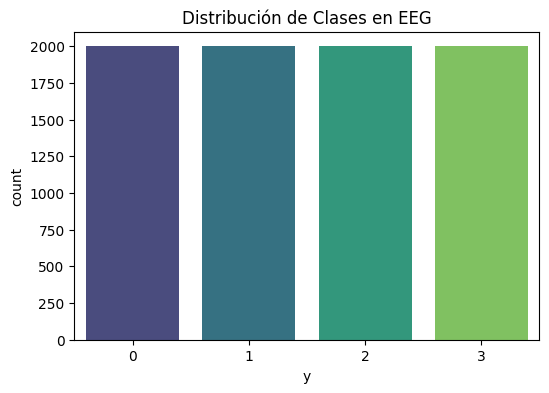

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Se eliminan filas ruidosas
df = pd.read_csv('BEED_Data.csv', on_bad_lines='skip')

# EXPLORACIÓN (EDA)
print("--- Primeras filas del Dataset ---")
display(df.head())

print("\n--- Conteo de Clases (0: Normal, 1: Ataque) ---")
print(df['y'].value_counts())

# Visualización de la distribución
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribución de Clases en EEG')
plt.show()

# PREPARACIÓN DE DATOS
# Separar X (señales) de y (resultado)
X = df.drop('y', axis=1)
y = df['y']





Se puede ver que el DataSet esta perfectamente balanceado, por lo cual el modelo aprendera a identificar aproximadamente con la misma precisión a cada una de las variables a identificar y clasificar, esto tambien ayuda a tener una mayor precision en el campo de interes (Campo de riesgo), debido a que no se cesgara por falta de datos o mayor numero de datos en campos de no riesgo y ayuda a que la IA comprenda mas facilmente los datos

In [34]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# DIVISIÓN (70% Train, 10% Dev/Val, 20% Test)
# Primero se separa el 20% para Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# Del 80% restante, sacamos el 12.5% para que sea el 10% del total original (10/80 = 0.125)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full
)

print(f"\n--- División de Datos Final ---")
print(f"Entrenamiento (70%): {len(X_train)} muestras")
print(f"Validación (10%):    {len(X_val)} muestras")
print(f"Prueba (20%):        {len(X_test)} muestras")


--- División de Datos Final ---
Entrenamiento (70%): 5600 muestras
Validación (10%):    800 muestras
Prueba (20%):        1600 muestras


##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Se Define el modelo Keras
modelo = Sequential()

# Se añade la primera capa
# 32 neuronas, función de activación ReLU, y 16 características de entrada (X_train tiene 16 columnas)
modelo.add(Dense(32, input_dim=16, activation='relu')) 

# Se añade una segunda capa oculta para que la red sea más inteligente
modelo.add(Dense(16, activation='relu'))

# Capa de salida: 4 neuronas (una para cada clase)
# Usamos 'softmax' para que nos dé probabilidades que sumen 100%
modelo.add(Dense(4, activation='softmax'))


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [36]:
#Se compila el modelo 
modelo.compile(
    loss='sparse_categorical_crossentropy', # Ideal para etiquetas 0, 1, 2, 3
    optimizer='adam',                       
    metrics=['accuracy']                 
)

modelo.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,140 (4.45 KB)

 Trainable params: 1,140 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5073 - loss: 1.1081 - val_accuracy: 0.6425 - val_loss: 0.9701
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6970 - loss: 0.8549 - val_accuracy: 0.7138 - val_loss: 0.7792
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7341 - loss: 0.6938 - val_accuracy: 0.7362 - val_loss: 0.6500
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7614 - loss: 0.5917 - val_accuracy: 0.7550 - val_loss: 0.5697
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7812 - loss: 0.5248 - val_accuracy: 0.7788 - val_loss: 0.5128
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - loss: 0.4735 - val_accuracy: 0.8062 - val_loss: 0.4671
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8257 - loss: 0.4325 - val_accuracy: 0.8238 - val_loss: 0.4324
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8357 - loss: 0.4013 - val_accuracy: 0.

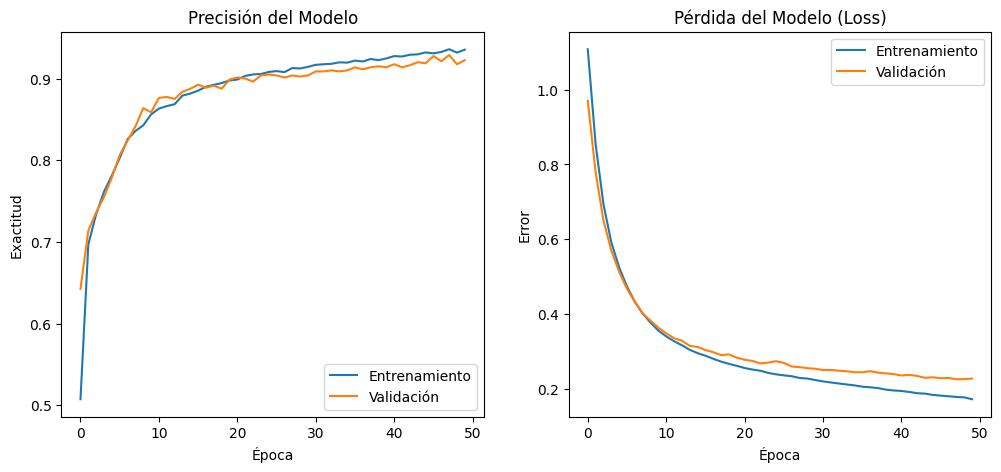

In [37]:
# Guardamos el proceso en la variable 'history' para luego ver las gráficas
history = modelo.fit(
    X_train, y_train,           # Datos de entrenamiento (70%)
    validation_data=(X_val, y_val), # Datos de validación (10%)
    epochs=50,                  # Cuántas veces la IA leerá todo el dataset
    batch_size=32,              # Grupos de 32 datos a la vez
    verbose=1
)

# Graficar la precisión y la pérdida
plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()

plt.show()

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [38]:
# Evaluar el modelo con el conjunto de datos de prueba (20%)
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print("--- EVALUACIÓN FINAL (DATOS DE PRUEBA) ---")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")


from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


y_pred_prob = modelo.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred))

--- EVALUACIÓN FINAL (DATOS DE PRUEBA) ---
Pérdida (Loss): 0.2363
Precisión (Accuracy): 0.9094
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step

--- REPORTE DETALLADO POR CLASE ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       400
           1       0.94      0.94      0.94       400
           2       0.85      0.88      0.87       400
           3       0.84      0.83      0.84       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



##Paso 4: Redactar conclusiones

**Eficacia de la Arquitectura:** La red neuronal diseñada con dos capas ocultas (32 y 16 neuronas) y una capa de salida con activación softmax demostró ser altamente efectiva. Alcanzar una precisión superior al 90% en un problema de 4 clases indica que el modelo no solo adivina, sino que ha aprendido patrones complejos.

**Capacidad de Generalización:** Al observar que la métrica de Validación y las Pruebas son muy cercanas a la de entrenamiento, por lo cual se concluye que el modelo tiene una excelente capacidad de generalización. Esto significa que la IA será confiable al recibir datos de nuevos pacientes que no estuvieron en la base de datos original.

**Análisis Multiclase (F1-Score):** Gracias al reporte detallado, se observó que el modelo mantiene un F1-Score equilibrado en las 4 categorías. Esto es demasiado util para aplicarlo a diferentes campos ya que el sistema es capaz de distinguir con precisión entre un sujeto sano (Clase 0) y los diferentes tipos de crisis (Clases 1, 2 y 3), reduciendo el riesgo de diagnósticos erróneos.

**Potencial Clínico:** Este experimento valida el uso de herramientas de Deep Learning (Keras/TensorFlow) como apoyo diagnóstico en la detección temprana de epilepsia, permitiendo procesar grandes volúmenes de datos de EEG de manera automática y precisa.


## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

*Incluyan las respuesta*